In [22]:
import numpy as np
import pandas as pd

import librosa
import librosa.display

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, DepthwiseConv2D, MaxPooling2D, GlobalAveragePooling2D, Conv2D
from tensorflow.keras.regularizers import l2

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

import seaborn as sns

import os
import shutil
import json

from pathlib import Path

In [23]:
#%pip install pandas librosa scikit-learn seaborn

In [24]:

DATASET_DIR = Path("Animal sound")
classes = ["Dog", "Cow", "Frog"]

rows = []
for label in classes:
    for wav_file in (DATASET_DIR / label).glob("*.wav"):
        rows.append({"filepath": str(wav_file), "label": label})

df = pd.DataFrame(rows)

train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

print("\nTrain dist:\n", train_df["label"].value_counts())
print("\nVal dist:\n", val_df["label"].value_counts())
print("\nTest dist:\n", test_df["label"].value_counts())

Train: 224
Val: 75
Test: 75

Train dist:
 label
Dog     94
Cow     68
Frog    62
Name: count, dtype: int64

Val dist:
 label
Dog     31
Cow     23
Frog    21
Name: count, dtype: int64

Test dist:
 label
Dog     31
Cow     23
Frog    21
Name: count, dtype: int64


>normalize_audio(...)
>
>get_audio_snippets_from_audio_file(...)
>
>extract_mfcc(...)
>
>the updated extract_mfccs_for_dataset(df) for your Dog/Cow/Frog dataset
>
>running it on train_df, val_df, test_df

In [25]:
# Set MFCC parameters
N_MFCC = 13 
N_MELS = 26
N_FRAMES = 200
SAMPLING_RATE = 16000 # 16 kHz
FRAME_SIZE = 512 # 32 ms
HOP_LENGTH = 256 # 16 ms
MIN_FREQ = 50
MAX_FREQ = SAMPLING_RATE / 2

In [26]:
# ----------------------------
# 1) Normalize audio
# ----------------------------
# Peak-normalize each audio clip: divide by the maximum absolute sample value so the
# waveform fits in [-1, 1]. This removes volume as a confounding factor (some files are
# louder/softer due to recording settings), stabilizes feature extraction (e.g., MFCCs),
# and typically improves training stability and generalization.

def normalize_audio(audio):
    # Normalize to range approximately [-1, 1]
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    return audio

In [27]:
# ----------------------------
# 2) Split one audio file into fixed-length snippets
# ----------------------------
# Split a variable-length .wav into fixed-length snippets so every training example has the same
# number of samples. We compute `target_length` (the exact samples needed to produce N_FRAMES
# with FRAME_SIZE and HOP_LENGTH), then:
# - If the audio is shorter than `target_length`, we pad it (centered) so it still becomes one snippet.
# - If longer, we cut it into full non-overlapping snippets of length `target_length`.
# - If there is leftover audio at the end (remainder), we pad it (centered) to form one last snippet.
# This standardizes input size for feature extraction (e.g., MFCCs) and lets the model train on
# multiple examples from a single long recording.

def get_audio_snippets_from_audio_file(audio_file):
    y, sr = librosa.load(audio_file, sr=SAMPLING_RATE)

    # Trim leading/trailing silence 
    #ADDED THIS
    y, _ = librosa.effects.trim(y, top_db=20)
    
    # total samples needed for one snippet
    target_length = FRAME_SIZE + (N_FRAMES - 1) * HOP_LENGTH

    audio_array = []

    if len(y) < target_length:
        # Pad if audio is shorter than needed
        padding_size = target_length - len(y)
        pad_left = padding_size // 2
        pad_right = padding_size - pad_left
        y = np.pad(y, (pad_left, pad_right))
        audio_array.append(y)
    else:
        # Split into full snippets
        num_audio_snippets = len(y) // target_length

        for i in range(num_audio_snippets):
            audio_snippet = y[i * target_length : (i + 1) * target_length]
            audio_array.append(audio_snippet)

        # Handle remainder by padding the last partial snippet
        remainder = len(y) % target_length
        if remainder > 0:
            audio_snippet = y[-remainder:]
            pad_left = (target_length - remainder) // 2
            pad_right = (target_length - remainder) - pad_left
            audio_snippet = np.pad(audio_snippet, (pad_left, pad_right))
            audio_array.append(audio_snippet)

    return np.array(audio_array)


In [28]:
# ----------------------------
# 3) Extract MFCC from one snippet
# ----------------------------
def extract_mfcc(data):
    mfcc = librosa.feature.mfcc(
        y=data,
        sr=SAMPLING_RATE,
        n_mfcc=N_MFCC,
        n_mels=N_MELS,
        n_fft=FRAME_SIZE,
        hop_length=HOP_LENGTH,
        fmin=MIN_FREQ,
        fmax=MAX_FREQ,
        window='hann',
        center=False,
        dct_type=2,
        norm='ortho',
        power=2,
    )
    return mfcc

In [29]:
# ----------------------------
# 4) Extract MFCCs for a dataframe
#    Expects df with columns: filepath, label
# ----------------------------
# Extract MFCC features + labels from a dataframe of audio files.
# For each row (audio file):
#   1) Load the file and split it into fixed-length snippets (so every example is same size).
#   2) For each snippet:
#        - Normalize amplitude (reduce loudness differences between recordings/snippets).
#        - Convert audio -> MFCC matrix (compact representation of the sound's timbre/spectrum).
#        - Store the MFCC and the corresponding class label.
# Returns:
#   mfccs: shape (num_snippets_total, ...mfcc_shape...)  # one MFCC per snippet
#   labels: shape (num_snippets_total,)                 # one label per snippet
# def extract_mfccs_for_dataset(df):
#     mfccs = []
#     labels = []

#     for _, row in df.iterrows():
#         audio_path = row["filepath"]
#         label = row["label"]

#         snippets = get_audio_snippets_from_audio_file(audio_path)

#         for snippet in snippets:
#             normalized_snippet = normalize_audio(snippet)
#             mfcc = extract_mfcc(normalized_snippet)
#             mfccs.append(mfcc)
#             labels.append(label)

#     mfccs = np.array(mfccs)
#     labels = np.array(labels)

#     return mfccs, labels

def extract_mfccs_for_dataset(df, rms_threshold=0.02):
    mfccs = []
    labels = []

    for _, row in df.iterrows():
        audio_path = row["filepath"]
        label = row["label"]
        snippets = get_audio_snippets_from_audio_file(audio_path)

        for snippet in snippets:
            snippet = normalize_audio(snippet)

            # Skip snippets that are mostly silence/background
            rms = np.sqrt(np.mean(snippet**2))
            if rms < rms_threshold:
                continue

            mfccs.append(extract_mfcc(snippet))
            labels.append(label)

    return np.array(mfccs), np.array(labels)


MFCC pipeline (roughly):

>1.Split audio into small time windows (frames)

>2.Compute a spectrum (what frequencies are present) for each frame

>3.Convert to Mel scale (more detail in low frequencies, less in high)

>4.Take log energies (compress loudness range)

>5.Apply a transform (DCT) → produces MFCC numbers

In [30]:

# ----------------------------
# 5) Run feature extraction
# ----------------------------
X_train, y_train = extract_mfccs_for_dataset(train_df)
X_val, y_val = extract_mfccs_for_dataset(val_df)
X_test, y_test = extract_mfccs_for_dataset(test_df)

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape, "y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)

print("Sample labels:", np.unique(y_train))

X_train shape: (277, 13, 200) y_train shape: (277,)
X_val shape: (92, 13, 200) y_val shape: (92,)
X_test shape: (94, 13, 200) y_test shape: (94,)
Sample labels: ['Cow' 'Dog' 'Frog']


### Understanding the shapes of `X_train` and `y_train`

Given:

- `X_train.shape = (288, 13, 200)`
- `y_train.shape = (288,)`

#### What `X_train.shape = (288, 13, 200)` means

- **288** = total number of **snippets** created from all training `.wav` files  
  (each audio file can produce multiple fixed-length snippets)

- **13** = number of **MFCC coefficients** per time frame (`n_mfcc = 13`)

- **200** = number of **time frames** per snippet  
  (because the snippet length + hop length were chosen to produce exactly 200 frames)

So each training example is one MFCC “feature map” of shape **(13 × 200)**.

#### What `y_train.shape = (288,)` means

- There is **one label per snippet**, so there are **288 labels** corresponding to the **288 MFCC samples** in `X_train`.

In [31]:
# Convert string class labels (e.g., "Dog", "Cow", "Frog") into numeric targets for model training.
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1) LabelEncoder maps each class name -> an integer ID
#    Example: "Cow"->0, "Dog"->1, "Frog"->2 (exact order depends on label_encoder.classes_)
label_encoder = LabelEncoder()

# Fit ONLY on training labels to define the mapping, then reuse the same mapping for val/test
# so the class IDs stay consistent across splits.
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

# Print the learned class order (this tells you which class corresponds to 0, 1, 2, ...)
print("Classes:", label_encoder.classes_)

# Number of unique classes (e.g., 3 for Dog/Cow/Frog)
num_classes = len(label_encoder.classes_)

# 2) Convert integer class IDs into one-hot vectors (needed if using categorical_crossentropy)
#    Example: class 1 with 3 classes -> [0, 1, 0]
#    Shapes become:
#      y_train_cat: (num_samples, num_classes)
#      y_val_cat:   (num_samples, num_classes)
#      y_test_cat:  (num_samples, num_classes)
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_val_cat = to_categorical(y_val_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("y_val_cat shape:", y_val_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

Classes: ['Cow' 'Dog' 'Frog']
y_train_cat shape: (277, 3)
y_val_cat shape: (92, 3)
y_test_cat shape: (94, 3)


In [32]:
# Add a channel dimension so MFCCs can be treated like "images" for a CNN.
# Before: (samples, n_mfcc, time)  -> (288, 13, 200)
# After:  (samples, n_mfcc, time, channels) -> (288, 13, 200, 1)
# Conv2D expects a 4D input tensor, so we use 1 channel (grayscale).
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train new shape:", X_train.shape)
print("X_val new shape:", X_val.shape)
print("X_test new shape:", X_test.shape)

X_train new shape: (277, 13, 200, 1)
X_val new shape: (92, 13, 200, 1)
X_test new shape: (94, 13, 200, 1)


In [33]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)   # should be 3
y_train_cat = to_categorical(y_train_enc, num_classes)
y_val_cat   = to_categorical(y_val_enc, num_classes)
y_test_cat  = to_categorical(y_test_enc, num_classes)

print("Classes:", le.classes_)
print("y_train_cat:", y_train_cat.shape)

Classes: ['Cow' 'Dog' 'Frog']
y_train_cat: (277, 3)


In [34]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

input_shape = X_train.shape[1:]  # (13, 200, 1)

model = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.DepthwiseConv2D((3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(num_classes, activation="softmax")  # 3 classes
])

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 13, 200, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 100, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 100, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 50, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 50, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 3, 50, 16)      │           160 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 25, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,731 (6.76 KB)

 Trainable params: 1,731 (6.76 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from sklearn.utils.class_weight import compute_class_weight

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)
]

# history = model.fit(
#     X_train, y_train_cat,
#     validation_data=(X_val, y_val_cat),
#     epochs=50,
#     batch_size=32,
#     callbacks=callbacks
# )


classes = np.arange(num_classes)  # [0,1,2]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("class_weight:", class_weight_dict)

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

class_weight: {0: np.float64(1.2477477477477477), 1: np.float64(0.7446236559139785), 2: np.float64(1.1687763713080168)}
Epoch 1/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3791 - loss: 1.3684 - val_accuracy: 0.5326 - val_loss: 0.9598 - learning_rate: 0.0010
Epoch 2/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4477 - loss: 1.0430 - val_accuracy: 0.6413 - val_loss: 0.8938 - learning_rate: 0.0010
Epoch 3/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5451 - loss: 0.9571 - val_accuracy: 0.6087 - val_loss: 0.8273 - learning_rate: 0.0010
Epoch 4/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6426 - loss: 0.8830 - val_accuracy: 0.7391 - val_loss: 0.7949 - learning_rate: 0.0010
Epoch 5/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6462 - loss: 0.8257 - val_accuracy: 0.8043 - val_loss: 0.7178 - learning_rate: 0.0010
Epoch 6/80
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6209 - loss: 0.7893 - val_accuracy: 0.7935 - val_loss: 0.6924 - learning_rat

In [36]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.9680851101875305


In [37]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test_enc, y_pred)
print("Confusion matrix:\n", cm)

print("\nReport:\n", classification_report(y_test_enc, y_pred, target_names=le.classes_))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Confusion matrix:
 [[24  2  0]
 [ 0 42  0]
 [ 0  1 25]]

Report:
               precision    recall  f1-score   support

         Cow       1.00      0.92      0.96        26
         Dog       0.93      1.00      0.97        42
        Frog       1.00      0.96      0.98        26

    accuracy                           0.97        94
   macro avg       0.98      0.96      0.97        94
weighted avg       0.97      0.97      0.97        94



In [38]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.str_('Cow'): np.int64(74), np.str_('Dog'): np.int64(124), np.str_('Frog'): np.int64(79)}


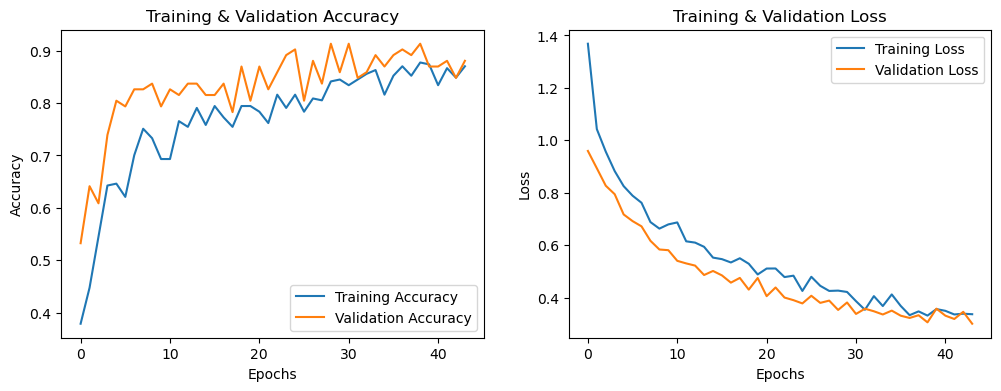

In [39]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training & Validation Loss')

plt.show()

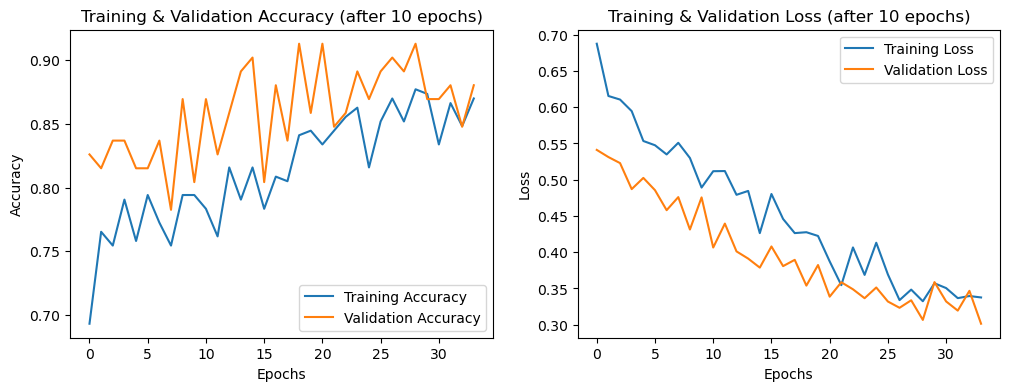

In [40]:
start_epoch = 10
if len(history.history['accuracy']) > start_epoch:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'][start_epoch:], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'][start_epoch:], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'Training & Validation Accuracy (after {start_epoch} epochs)')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'][start_epoch:], label='Training Loss')
    plt.plot(history.history['val_loss'][start_epoch:], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Training & Validation Loss (after {start_epoch} epochs)')

    plt.show()
else:
    print(f"Not enough epochs to plot after epoch {start_epoch}.")

In [41]:
# -------------------------
# 3) Evaluate model on test set
# -------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.28194335103034973
Test accuracy: 0.9680851101875305


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Classification report:

              precision    recall  f1-score   support

         Cow       1.00      0.92      0.96        26
         Dog       0.93      1.00      0.97        42
        Frog       1.00      0.96      0.98        26

    accuracy                           0.97        94
   macro avg       0.98      0.96      0.97        94
weighted avg       0.97      0.97      0.97        94



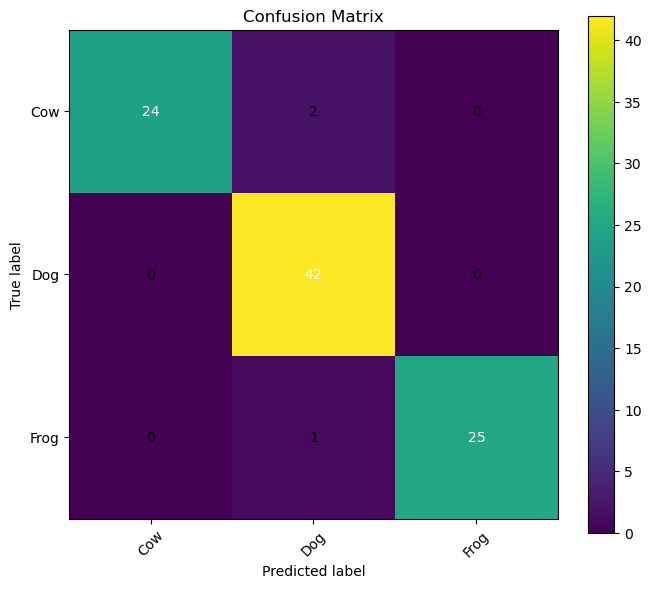

In [42]:
# -------------------------
# 4) Predictions + confusion matrix
# -------------------------
pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)       # predicted class index
y_true = np.argmax(y_test_cat, axis=1)       # true class index

# Print classification report
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)

# Add numbers in cells
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import tensorflow as tf

def representative_dataset():
    # Use a small subset of training samples
    # Pick ~100-300 samples typically
    num_samples = min(200, X_train.shape[0])
    indices = np.random.choice(X_train.shape[0], num_samples, replace=False)

    for i in indices:
        # Must yield a list of input tensors
        x = X_train[i:i+1].astype(np.float32)
        yield [x]

In [44]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Force full int8 quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_int8 = converter.convert()

with open("animal_sound_int8.tflite", "wb") as f:
    f.write(tflite_model_int8)

print("Saved: animal_sound_int8.tflite", len(tflite_model_int8), "bytes")

INFO:tensorflow:Assets written to: /var/folders/bv/tfwhqkk15gbftldy9qz7nm3c0000gr/T/tmpcf7y0ker/assets


INFO:tensorflow:Assets written to: /var/folders/bv/tfwhqkk15gbftldy9qz7nm3c0000gr/T/tmpcf7y0ker/assets


Saved artifact at '/var/folders/bv/tfwhqkk15gbftldy9qz7nm3c0000gr/T/tmpcf7y0ker'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 200, 1), dtype=tf.float32, name='keras_tensor_12')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  6057875536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6057873040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6057881488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6057881680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6058949712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6046750992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6046748304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6046744848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6046747344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6046750224: TensorSpec(shape=(), dtype=tf.resource, name=None)


/opt/anaconda3/envs/tf/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1772700382.931347  243310 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1772700382.934322  243310 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-03-05 16:46:22.937456: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/bv/tfwhqkk15gbftldy9qz7nm3c0000gr/T/tmpcf7y0ker
2026-03-05 16:46:22.937900: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-03-05 16:46:22.937907: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/bv/tfwhqkk15gbftldy9qz7nm3c0000gr/T/tmpcf7y0ker
I0000 00:00:1772700382.943542  243310 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-03-05 16:46:22.944263: I te

Saved: animal_sound_int8.tflite 7976 bytes


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-03-05 16:46:23.501972: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [45]:
import numpy as np
import tensorflow as tf

# Load the int8 model
interpreter = tf.lite.Interpreter(model_path="animal_sound_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:", input_details)
print("Output:", output_details)

# Quantization params
in_scale, in_zero = input_details[0]["quantization"]
out_scale, out_zero = output_details[0]["quantization"]

def predict_tflite_int8(X):
    preds = []
    for i in range(X.shape[0]):
        x = X[i:i+1].astype(np.float32)

        # Quantize input float -> int8
        x_int8 = (x / in_scale + in_zero).round().astype(np.int8)

        interpreter.set_tensor(input_details[0]["index"], x_int8)
        interpreter.invoke()

        y_int8 = interpreter.get_tensor(output_details[0]["index"])

        # Dequantize output int8 -> float (optional, but useful)
        y = (y_int8.astype(np.float32) - out_zero) * out_scale
        preds.append(y[0])

    return np.array(preds)

# Get predictions
pred_probs = predict_tflite_int8(X_test)
y_pred = np.argmax(pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

acc = (y_pred == y_true).mean()
print("TFLite INT8 Test Accuracy:", acc)

Input: [{'name': 'serving_default_keras_tensor_12:0', 'index': 0, 'shape': array([  1,  13, 200,   1], dtype=int32), 'shape_signature': array([ -1,  13, 200,   1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (1.997370958328247, 66), 'quantization_parameters': {'scales': array([1.997371], dtype=float32), 'zero_points': array([66], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'StatefulPartitionedCall_1:0', 'index': 21, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
TFLite INT8 Test Accuracy: 0.9680851063829787


/opt/anaconda3/envs/tf/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Applying 1 TensorFlow Lite delegate(s) lazily.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
VERBOSE: XNNPack weight cache not enabled.
VERBOSE: Replacing 9 out of 10 node(s) with delegate (TfLiteXNNPackDelegate) node, yielding 2 partitions for subgraph 0.
INFO: Successfully applied the default TensorFlow Lite delegate indexed at 0.
 *NOTE*: because a delegate has been applied, the precision of computations should be unchanged, but the exact output tensor values may have changed. If such output values are checked in your code, like in your tests etc., please conside

In [46]:
# Convert .tflite file to a C header array (no external tools needed)

tflite_path = "animal_sound_int8.tflite"
header_path = "animal_sound_model.h"
array_name = "animal_sound_model"

with open(tflite_path, "rb") as f:
    data = f.read()

with open(header_path, "w") as f:
    f.write("#pragma once\n\n")
    f.write(f"const unsigned char {array_name}[] = {{\n")

    for i, b in enumerate(data):
        if i % 12 == 0:
            f.write("  ")
        f.write(f"0x{b:02x}, ")
        if i % 12 == 11:
            f.write("\n")

    f.write("\n};\n")
    f.write(f"const unsigned int {array_name}_len = {len(data)};\n")

print("Saved header:", header_path, "bytes:", len(data))

Saved header: animal_sound_model.h bytes: 7976


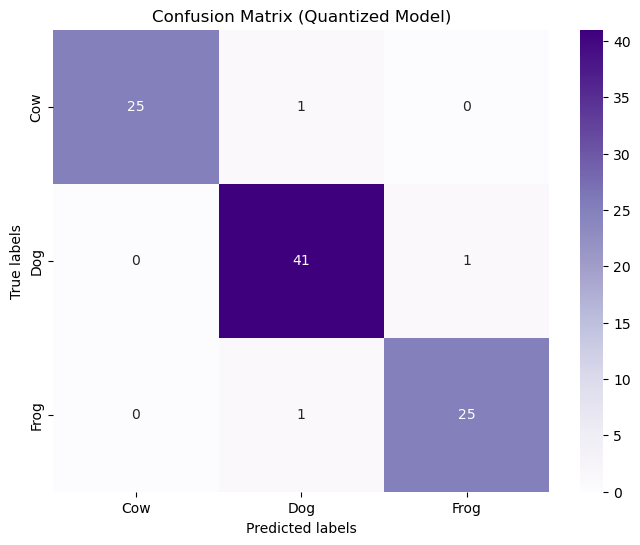

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_q = confusion_matrix(y_true, y_pred_q)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_q, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Purples')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix (Quantized Model)')
plt.show()